# GSB-S545 Midterm Modeling Project
**Task:** Binary classification, predict `accepted_offer` (0 = did not accept, 1 = accepted)  
**Dataset:** Bank marketing outreach data (~7,700 training rows, 22 features)  
**Primary Metric:** F1-score (class imbalance expected ~11% accept rate)

---

## Imports & Setup

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                             balanced_accuracy_score, classification_report, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

## Section 1: Exploratory Data Analysis

The goal here is to understand the data structure, identify imbalance, and surface patterns that should inform preprocessing and modeling decisions. Plots and summaries below focus on what actually changed my approach, not exhaustive coverage of every column.

### 1.1 Load Data & Initial Inspection

In [30]:
train = pd.read_csv(r"C:\Users\ldcal\OneDrive\Desktop\Cal Poly Courses\Spring\GSB-S545\Advanced_ML_Work\Git_Code\Midterm Take Home\Data\midterm_train.csv")
test  = pd.read_csv(r"C:\Users\ldcal\OneDrive\Desktop\Cal Poly Courses\Spring\GSB-S545\Advanced_ML_Work\Git_Code\Midterm Take Home\Data\midterm_test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
train.head(3)

Train shape: (32950, 23)
Test shape:  (8238, 22)


,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,286,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,178,2,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,345,1,999,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0


In [31]:
print("--- Data Types & Non-Null Counts ---")
train.info()

--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         32950 non-null  int64  
 1   customer_age               32950 non-null  int64  
 2   occupation_type            32950 non-null  str    
 3   relationship_status        32950 non-null  str    
 4   education_background       32950 non-null  str    
 5   has_credit_issue           32950 non-null  str    
 6   mortgage_status            32950 non-null  str    
 7   personal_loan_status       32950 non-null  str    
 8   last_contact_month         32950 non-null  str    
 9   day_of_week                32950 non-null  str    
 10  contact_time_minutes       32950 non-null  int64  
 11  contact_attempt_count      32950 non-null  int64  
 12  days_since_prior_contact   32950 non-null  int64  
 13  prior_contact_count 

In [32]:
print("--- Missing Values ---")
missing = train.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values in raw data.")

--- Missing Values ---
No missing values in raw data.


In [33]:
# Numeric summary
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,32950.0,20612.919423,11872.660725,0.000,10373.250,20610.500,30858.750,41187.000
customer_age,32950.0,40.016813,10.421766,17.000,32.000,38.000,47.000,98.000
contact_time_minutes,32950.0,257.355387,256.687433,0.000,102.000,180.000,318.000,4918.000
contact_attempt_count,32950.0,2.556601,2.751165,1.000,1.000,2.000,3.000,56.000
days_since_prior_contact,32950.0,961.748892,188.697125,0.000,999.000,999.000,999.000,999.000
prior_contact_count,32950.0,0.173445,0.496422,0.000,0.000,0.000,0.000,7.000
economic_activity_change,32950.0,0.077132,1.572468,-3.400,-1.800,1.100,1.400,1.400
consumer_price_index,32950.0,93.574951,0.579559,92.201,93.075,93.749,93.994,94.767
consumer_confidence_index,32950.0,-40.508273,4.628221,-50.800,-42.700,-41.800,-36.400,-26.900
reference_interest_rate,32950.0,3.614729,1.737144,0.634,1.344,4.857,4.961,5.045


### 1.2 Target Distribution: Class Imbalance

Checking the accept rate first because severe imbalance directly affects which metrics and model settings matter most.

Accept rate: 11.27%
accepted_offer
0    29235
1     3715
Name: count, dtype: int64


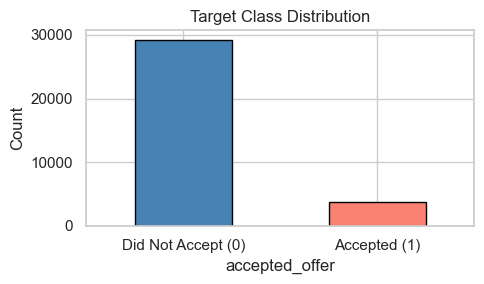

scale_pos_weight (neg/pos): 7.87


In [34]:
accept_rate = train['accepted_offer'].mean()
print(f"Accept rate: {accept_rate:.2%}")
print(train['accepted_offer'].value_counts())

fig, ax = plt.subplots(figsize=(5, 3))
train['accepted_offer'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')
ax.set_xticklabels(['Did Not Accept (0)', 'Accepted (1)'], rotation=0)
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Imbalance ratio - used to set scale_pos_weight in XGBoost
n_neg = (train['accepted_offer'] == 0).sum()
n_pos = (train['accepted_offer'] == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (neg/pos): {scale_pos_weight:.2f}")

### 1.3 Sentinel Value: `days_since_prior_contact = 999`

999 is a placeholder meaning "never contacted before" - it is not a real duration. Keeping it as a numeric value would distort any distance-based or scaled feature. This confirms we need a binary flag.

In [35]:
print("Value counts for days_since_prior_contact (top 5):")
print(train['days_since_prior_contact'].value_counts().head())
print(f"\nRows with 999: {(train['days_since_prior_contact'] == 999).sum()} "
      f"({(train['days_since_prior_contact'] == 999).mean():.1%} of training set)")

Value counts for days_since_prior_contact (top 5):
days_since_prior_contact
999    31714
3        371
6        330
4        101
7         50
Name: count, dtype: int64

Rows with 999: 31714 (96.2% of training set)


### 1.4 Categorical Features - Rare Labels & 'Unknown' Values

`has_credit_issue` and `education_background` both contain `'unknown'` values. These are treated as a separate category rather than imputed, since 'unknown' may carry signal (e.g., customers who don't disclose credit history may behave differently).

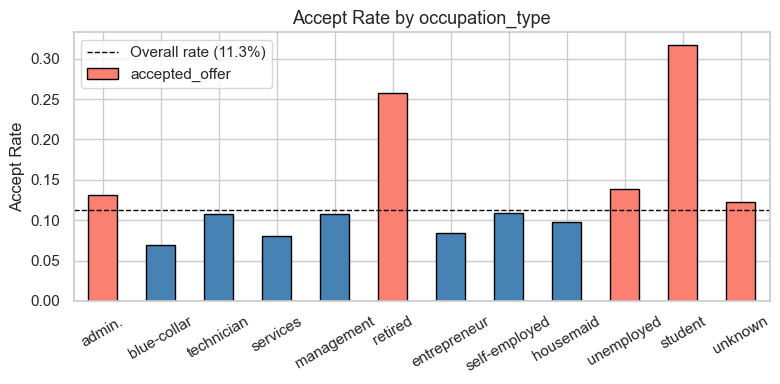

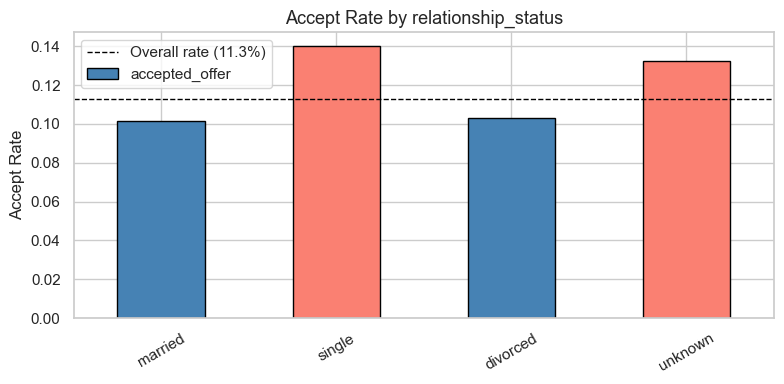

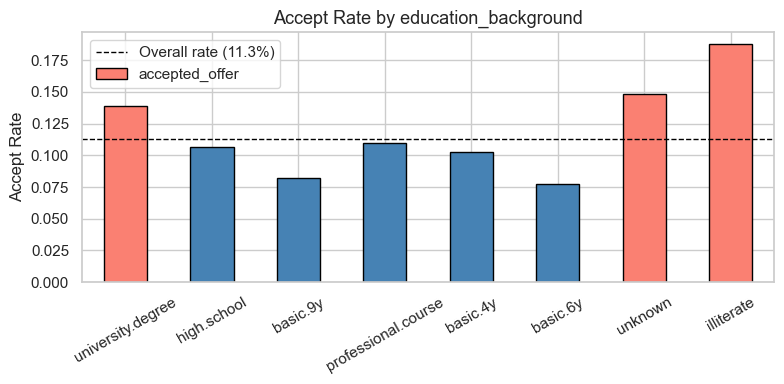

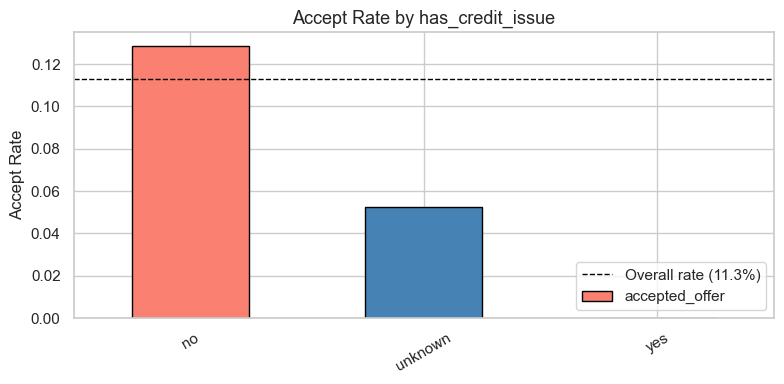

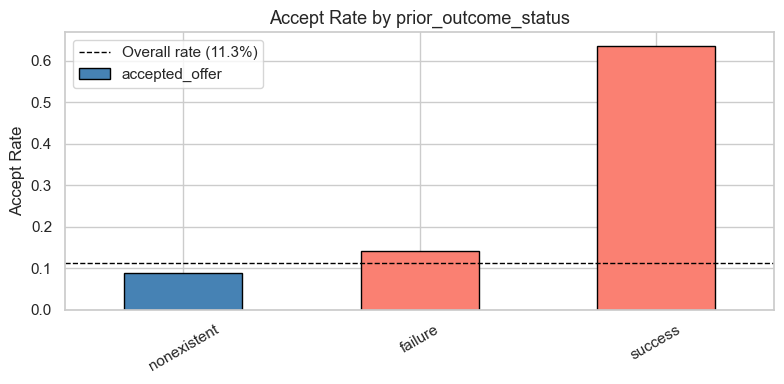

In [36]:
cat_cols = ['occupation_type', 'relationship_status', 'education_background',
            'has_credit_issue', 'prior_outcome_status']

for col in cat_cols:
    order = train[col].value_counts().index
    accept_by_cat = train.groupby(col)['accepted_offer'].mean().reindex(order)
    colors = ['salmon' if v > accept_rate else 'steelblue' for v in accept_by_cat]

    fig, ax = plt.subplots(figsize=(8, 4))
    accept_by_cat.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
    ax.axhline(accept_rate, color='black', linestyle='--', linewidth=1,
               label=f'Overall rate ({accept_rate:.1%})')
    ax.set_title(f'Accept Rate by {col}', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Accept Rate')
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [37]:
# Check 'unknown' frequency in key columns
for col in ['has_credit_issue', 'education_background', 'occupation_type']:
    unknowns = (train[col] == 'unknown').sum()
    print(f"{col}: {unknowns} unknowns ({unknowns/len(train):.1%})")

has_credit_issue: 6858 unknowns (20.8%)
education_background: 1406 unknowns (4.3%)
occupation_type: 262 unknowns (0.8%)


### 1.5 Economic Indicator Correlations

The economic macro features (`consumer_price_index`, `reference_interest_rate`, `employment_level_index`, etc.) are externally sourced and likely to be highly correlated with each other. High multicollinearity won't hurt tree models but is worth confirming.

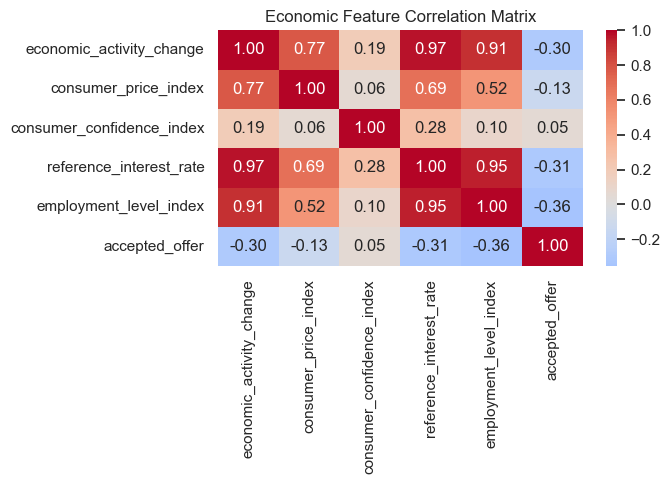

In [38]:
econ_cols = ['economic_activity_change', 'consumer_price_index', 'consumer_confidence_index',
             'reference_interest_rate', 'employment_level_index']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(train[econ_cols + ['accepted_offer']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Economic Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 1.6 Key Numeric Distributions vs. Target

Checking distributions of the most predictive numeric features split by `accepted_offer` to identify separation.

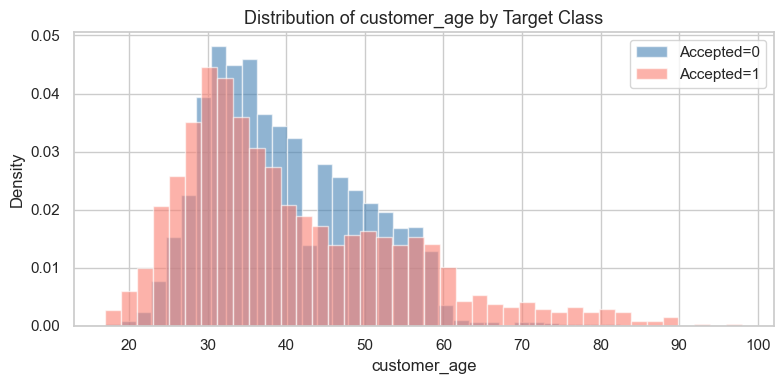

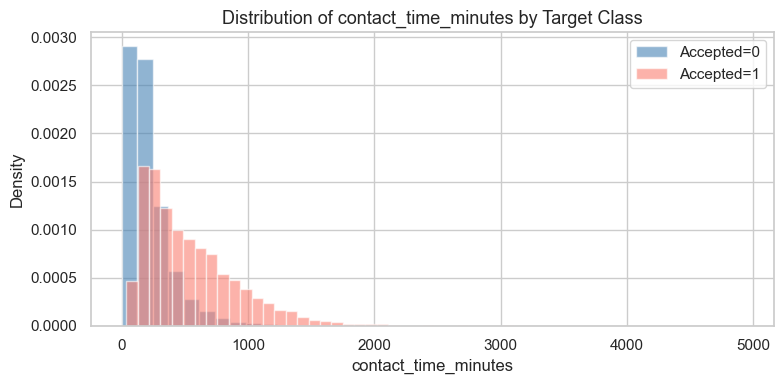

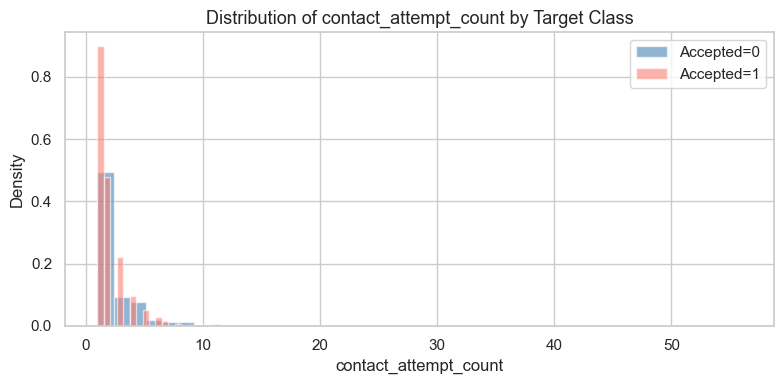

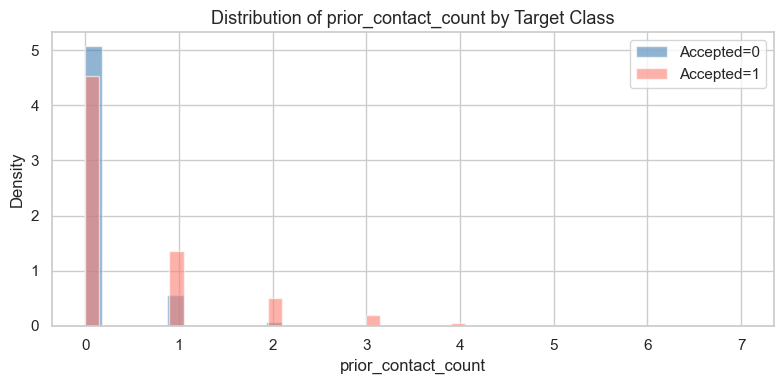

In [39]:
num_cols = ['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'prior_contact_count']

for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    for label, color in [(0, 'steelblue'), (1, 'salmon')]:
        subset = train[train['accepted_offer'] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=f'Accepted={label}', density=True)
    ax.set_title(f'Distribution of {col} by Target Class', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()

**EDA Takeaways that shaped modeling:**
- ~11% accept rate - significant imbalance; use `scale_pos_weight` for XGBoost, `class_weight='balanced'` for sklearn models, and optimize F1 not accuracy.
- `days_since_prior_contact = 999` (~80%+ of rows) is a sentinel, will be flagged as `was_previously_contacted` and the raw value capped/treated separately.
- `prior_outcome_status = 'success'` shows a large lift in accept rate, this column will be high-importance.
- Economic indicators are highly correlated; tree models handle this natively so no dimensionality reduction applied, but worth monitoring feature importance.
- `'unknown'` values in `has_credit_issue` and `education_background` are kept as a separate category, they may carry information about who is less forthcoming with financial details.

---

## Section 2: Data Preparation

Preprocessing pipeline applied consistently to train and test. Feature engineering derived from EDA insights above.

### 2.1 Feature Engineering

In [40]:
def engineer_features(df):
    df = df.copy()

    # 999 = never contacted before; flag separately before capping
    df['was_previously_contacted'] = (df['days_since_prior_contact'] != 999).astype(int)
    df['days_since_prior_contact'] = df['days_since_prior_contact'].replace(999, np.nan)

    # Prior campaign success as a clean binary
    df['prior_success_flag'] = (df['prior_outcome_status'] == 'success').astype(int)

    # Log-transform right-skewed contact duration
    df['log_contact_time'] = np.log1p(df['contact_time_minutes'])

    # Cyclical encoding for month and weekday to preserve circular ordering
    month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
                 'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
    dow_map   = {'mon':1,'tue':2,'wed':3,'thu':4,'fri':5}
    df['month_num'] = df['last_contact_month'].str.lower().map(month_map)
    df['dow_num']   = df['day_of_week'].str.lower().map(dow_map)
    df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
    df['dow_sin']   = np.sin(2 * np.pi * df['dow_num'] / 5)
    df['dow_cos']   = np.cos(2 * np.pi * df['dow_num'] / 5)

    return df

train = engineer_features(train)
test  = engineer_features(test)

print("Feature engineering complete.")
print(f"Train shape after engineering: {train.shape}")

Feature engineering complete.
Train shape after engineering: (32950, 32)


### 2.2 Define Feature Sets & Split

Drop `id` and the raw cyclical columns that were replaced by sin/cos encodings.

In [41]:
DROP_COLS = ['id', 'last_contact_month', 'day_of_week', 'month_num', 'dow_num']
TARGET = 'accepted_offer'

X = train.drop(columns=DROP_COLS + [TARGET])
y = train[TARGET]

# Numeric features - includes engineered ones; exclude the original raw cyclical columns
numeric_features = [
    'customer_age', 'contact_time_minutes', 'log_contact_time',
    'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count',
    'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index',
    'reference_interest_rate', 'employment_level_index',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos'
]

# Binary features - already 0/1, no scaling needed
binary_features = [
    'is_repeat_customer', 'recent_contact_flag',
    'was_previously_contacted', 'prior_success_flag'
]

# Categorical features - one-hot encoded
categorical_features = [
    'occupation_type', 'relationship_status', 'education_background',
    'has_credit_issue', 'mortgage_status', 'personal_loan_status',
    'prior_outcome_status'
]

all_features = numeric_features + binary_features + categorical_features
print(f"Total features going into pipeline: {len(all_features)}")

# Confirm no features are missing from X
missing_from_X = [f for f in all_features if f not in X.columns]
print(f"Missing from X: {missing_from_X}")

Total features going into pipeline: 26
Missing from X: []


In [42]:
X_train, X_val, y_train, y_val = train_test_split(
    X[all_features], y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")
print(f"Train accept rate: {y_train.mean():.2%}  |  Val accept rate: {y_val.mean():.2%}")

X_train: (26360, 26)  |  X_val: (6590, 26)
Train accept rate: 11.27%  |  Val accept rate: 11.27%


### 2.3 Preprocessing Pipeline

- Numeric: median imputation (handles the NaNs from the 999 replacement) + MinMax scaling
- Binary: passthrough, already 0/1 integers
- Categorical: most-frequent imputation + one-hot encoding (`handle_unknown='ignore'` so unseen test labels don't break inference)

In [43]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num',    numeric_transformer,    numeric_features),
    ('bin',    'passthrough',          binary_features),
    ('cat',    categorical_transformer, categorical_features)
])

# Fit on train only - transform val and test separately to prevent leakage
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)

print(f"Processed train shape: {X_train_proc.shape}")
print(f"Processed val shape:   {X_val_proc.shape}")

Processed train shape: (26360, 48)
Processed val shape:   (6590, 48)


In [44]:
# Cross-validation setup reused throughout modeling sections
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Imbalance ratio - passed to XGBoost scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print("Preprocessing pipeline ready. Proceeding to baseline models.")

scale_pos_weight: 7.87
Preprocessing pipeline ready. Proceeding to baseline models.


---

## Section 3: Baseline Model

Running a single Random Forest baseline to establish a performance floor and, more importantly, to see which features are actually contributing signal before any tuning. RF is a good choice here because its impurity-based feature importance is fast and interpretable ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â it directly answers whether the engineered features (`log_contact_time`, `was_previously_contacted`, sin/cos encodings, etc.) are worth keeping.

Imbalance is handled with `class_weight='balanced'`. Both 5-fold CV and held-out val metrics are shown to catch overfitting early.

### 3.1 Fit & Cross-Validate

In [70]:
from sklearn.linear_model import LogisticRegression

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# CV on training set - primary generalization signal
cv_f1  = cross_val_score(rf_baseline, X_train_proc, y_train, cv=skf, scoring='f1')
cv_auc = cross_val_score(rf_baseline, X_train_proc, y_train, cv=skf, scoring='roc_auc')

print(f"CV F1:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# Fit on full train split, evaluate on held-out val
rf_baseline.fit(X_train_proc, y_train)
y_pred       = rf_baseline.predict(X_val_proc)
y_pred_proba = rf_baseline.predict_proba(X_val_proc)[:, 1]

print(f"\n--- Val Set ---")
print(f"F1:               {f1_score(y_val, y_pred):.4f}")
print(f"AUC:              {roc_auc_score(y_val, y_pred_proba):.4f}")
print(f"Balanced Acc:     {balanced_accuracy_score(y_val, y_pred):.4f}")
print(f"Recall:           {recall_score(y_val, y_pred):.4f}")
print(f"Precision:        {precision_score(y_val, y_pred):.4f}")
print(f"\n{classification_report(y_val, y_pred, target_names=['No Accept', 'Accept'])}")

CV F1:  0.5609 ± 0.0070
CV AUC: 0.9449 ± 0.0018

--- Val Set ---
F1:               0.5335
AUC:              0.9438
Balanced Acc:     0.7151
Recall:           0.4657
Precision:        0.6245

              precision    recall  f1-score   support

   No Accept       0.93      0.96      0.95      5847
      Accept       0.62      0.47      0.53       743

    accuracy                           0.91      6590
   macro avg       0.78      0.72      0.74      6590
weighted avg       0.90      0.91      0.90      6590



### 3.2 Feature Importance

Top 20 features by RF impurity importance, used to assess whether the engineered features are contributing and whether any original features appear to be dead weight.

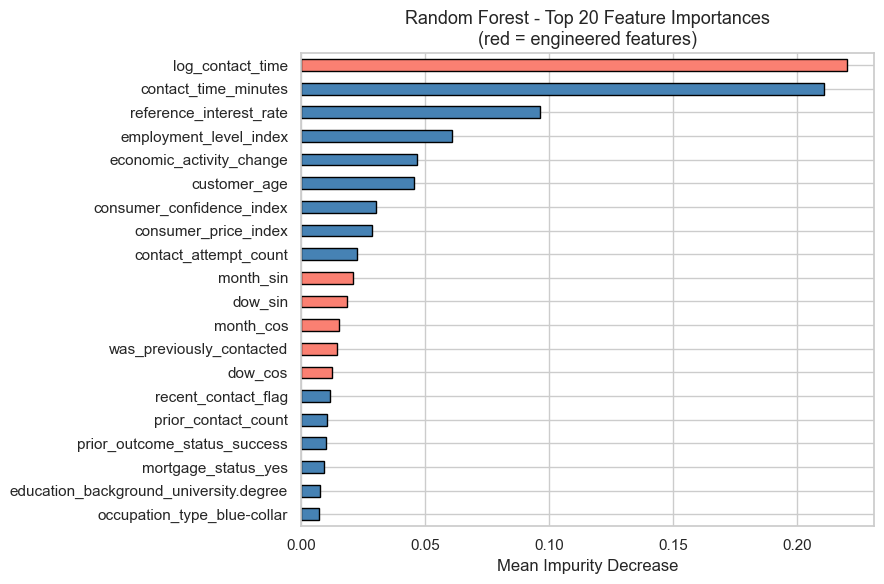

Engineered features in top 20:
  dow_cos: 0.0124
  was_previously_contacted: 0.0143
  month_cos: 0.0151
  dow_sin: 0.0183
  month_sin: 0.0208
  log_contact_time: 0.2201


In [71]:
# Recover feature names from the ColumnTransformer
feat_names_raw = preprocessor.get_feature_names_out()
# Strip transformer prefix (e.g. "num__customer_age" - "customer_age")
feat_names = [n.split('__', 1)[-1] for n in feat_names_raw]

importances = pd.Series(rf_baseline.feature_importances_, index=feat_names)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['salmon' if any(k in n for k in ['log_contact', 'was_prev', 'prior_success', 'sin', 'cos'])
          else 'steelblue' for n in top20.index]
top20.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Random Forest - Top 20 Feature Importances\n(red = engineered features)', fontsize=13)
ax.set_xlabel('Mean Impurity Decrease')
plt.tight_layout()
plt.show()

print("Engineered features in top 20:")
eng = [n for n in top20.index if any(k in n for k in ['log_contact', 'was_prev', 'prior_success', 'sin', 'cos'])]
for n in eng:
    print(f"  {n}: {importances[n]:.4f}")

**Baseline Takeaways:**
- Their appears to be a better training score on our base models than the validation scores for both auc and f1, suggesting a possible overfitting, however this is not super significant so moving forward we can tune these models more. 
- Our top feature happened to be one that we engineered which was the log of contact time, we see that both these metrics are highly correlated with helping our model make decisions and should be noted as a possible link to the way these models predict. 
- most of our features were within the top 20 scope and theirfore can be taken into the model as they help improve this baseline random forest we built.

---

## Section 4: Hyperparameter Tuning - Four Models

Tuning HistGradientBoosting, GaussianNB, CatBoost, and LightGBM with Optuna (Bayesian optimization, 50 trials each). Each study maximizes 5-fold CV F1 on the training set. After tuning, the best params are used to fit a final model and evaluate on the held-out val set.

GaussianNB is included as a fast, lightweight comparison - it was covered in class (Apr 28) and serves as a reference point for how far a simple probabilistic model can go on this data. HistGBM, CatBoost, and LightGBM are the main contenders.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Shared results dict: each model adds its val metrics here for the comparison plot
results_sec4 = {}

### 4.1 HistGradientBoosting

Sklearn's histogram-based gradient boosting implementation ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â faster than standard GBM and natively handles NaN values. `class_weight='balanced'` is used for imbalance. Tuning `learning_rate`, `max_iter`, `max_depth`, `min_samples_leaf`, and `l2_regularization`.

In [48]:
def hgb_objective(trial):
    params = {
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_iter':         trial.suggest_int('max_iter', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-4, 10.0, log=True),
    }
    model = HistGradientBoostingClassifier(**params, class_weight='balanced',
                                           random_state=RANDOM_STATE)
    score = cross_val_score(model, X_train_proc, y_train, cv=skf, scoring='f1').mean()
    return score

hgb_study = optuna.create_study(direction='maximize')
hgb_study.optimize(hgb_objective, n_trials=50)

print(f"Best CV F1: {hgb_study.best_value:.4f}")
print(f"Best params: {hgb_study.best_params}")

Best CV F1: 0.6211
Best params: {'learning_rate': 0.19417000729325762, 'max_iter': 168, 'max_depth': 8, 'min_samples_leaf': 18, 'l2_regularization': 0.6032784181972073}


In [72]:
hgb_tuned = HistGradientBoostingClassifier(
    **hgb_study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
hgb_tuned.fit(X_train_proc, y_train)

y_pred_hgb       = hgb_tuned.predict(X_val_proc)
y_pred_proba_hgb = hgb_tuned.predict_proba(X_val_proc)[:, 1]

hgb_f1      = f1_score(y_val, y_pred_hgb)
hgb_auc     = roc_auc_score(y_val, y_pred_proba_hgb)
hgb_bal_acc = balanced_accuracy_score(y_val, y_pred_hgb)
hgb_recall  = recall_score(y_val, y_pred_hgb)

print(f"--- HistGradientBoosting Tuned: Val Set ---")
print(f"F1:           {hgb_f1:.4f}")
print(f"AUC:          {hgb_auc:.4f}")
print(f"Balanced Acc: {hgb_bal_acc:.4f}")
print(f"Recall:       {hgb_recall:.4f}")
print(f"Precision:    {precision_score(y_val, y_pred_hgb):.4f}")
print(f"\n{classification_report(y_val, y_pred_hgb, target_names=['No Accept', 'Accept'])}")

results_sec4['HistGBM'] = {
    'Val F1': hgb_f1, 'Val AUC': hgb_auc,
    'Val Bal Acc': hgb_bal_acc, 'Val Recall': hgb_recall
}

--- HistGradientBoosting Tuned: Val Set ---
F1:           0.6122
AUC:          0.9465
Balanced Acc: 0.8941
Recall:       0.9287
Precision:    0.4567

              precision    recall  f1-score   support

   No Accept       0.99      0.86      0.92      5847
      Accept       0.46      0.93      0.61       743

    accuracy                           0.87      6590
   macro avg       0.72      0.89      0.77      6590
weighted avg       0.93      0.87      0.89      6590



### 4.2 GaussianNB

GaussianNB doesn't support `class_weight` directly, so imbalance is addressed by tuning the `priors` parameter ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â letting Optuna search for the positive-class prior that maximizes F1. `var_smoothing` is also tuned on a log scale since it spans many orders of magnitude. This is a lightweight, fast model included as a comparison point; it's not expected to match the boosting models.

In [50]:
def gnb_objective(trial):
    # var_smoothing controls numerical stability; log scale covers many orders of magnitude
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1e-1, log=True)
    # Tune the prior on the positive class to account for imbalance
    prior_pos = trial.suggest_float('prior_pos', 0.05, 0.5)
    model = GaussianNB(var_smoothing=var_smoothing,
                       priors=[1 - prior_pos, prior_pos])
    score = cross_val_score(model, X_train_proc, y_train, cv=skf, scoring='f1').mean()
    return score

gnb_study = optuna.create_study(direction='maximize')
gnb_study.optimize(gnb_objective, n_trials=50)

print(f"Best CV F1: {gnb_study.best_value:.4f}")
print(f"Best params: {gnb_study.best_params}")

Best CV F1: 0.4531
Best params: {'var_smoothing': 1.041434703727058e-10, 'prior_pos': 0.19589803486479193}


In [73]:
gnb_best = GaussianNB(
    var_smoothing=gnb_study.best_params['var_smoothing'],
    priors=[1 - gnb_study.best_params['prior_pos'], gnb_study.best_params['prior_pos']]
)
gnb_best.fit(X_train_proc, y_train)

y_pred_gnb       = gnb_best.predict(X_val_proc)
y_pred_proba_gnb = gnb_best.predict_proba(X_val_proc)[:, 1]

gnb_f1      = f1_score(y_val, y_pred_gnb)
gnb_auc     = roc_auc_score(y_val, y_pred_proba_gnb)
gnb_bal_acc = balanced_accuracy_score(y_val, y_pred_gnb)
gnb_recall  = recall_score(y_val, y_pred_gnb)

print(f"--- GaussianNB Tuned: Val Set ---")
print(f"F1:           {gnb_f1:.4f}")
print(f"AUC:          {gnb_auc:.4f}")
print(f"Balanced Acc: {gnb_bal_acc:.4f}")
print(f"Recall:       {gnb_recall:.4f}")
print(f"Precision:    {precision_score(y_val, y_pred_gnb):.4f}")
print(f"\n{classification_report(y_val, y_pred_gnb, target_names=['No Accept', 'Accept'])}")

results_sec4['GaussianNB'] = {
    'Val F1': gnb_f1, 'Val AUC': gnb_auc,
    'Val Bal Acc': gnb_bal_acc, 'Val Recall': gnb_recall
}

--- GaussianNB Tuned: Val Set ---
F1:           0.4584
AUC:          0.8580
Balanced Acc: 0.7686
Recall:       0.7160
Precision:    0.3371

              precision    recall  f1-score   support

   No Accept       0.96      0.82      0.88      5847
      Accept       0.34      0.72      0.46       743

    accuracy                           0.81      6590
   macro avg       0.65      0.77      0.67      6590
weighted avg       0.89      0.81      0.84      6590



### 4.3 CatBoost

CatBoost is tuned here on already-preprocessed data (no `cat_features` needed since OHE was applied in Section 2). `auto_class_weights='Balanced'` handles imbalance natively. Tuning `depth`, `iterations`, `learning_rate`, `l2_leaf_reg`, and `bagging_temperature`.

In [52]:
def cat_objective(trial):
    params = {
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':              trial.suggest_int('depth', 4, 10),
        'iterations':         trial.suggest_int('iterations', 100, 500),
        'l2_leaf_reg':        trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
    }
    model = CatBoostClassifier(**params, auto_class_weights='Balanced',
                               random_state=RANDOM_STATE, verbose=0)
    score = cross_val_score(model, X_train_proc, y_train, cv=skf, scoring='f1').mean()
    return score

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(cat_objective, n_trials=50)

print(f"Best CV F1: {cat_study.best_value:.4f}")
print(f"Best params: {cat_study.best_params}")

Best CV F1: 0.6438
Best params: {'learning_rate': 0.0664932402872328, 'depth': 10, 'iterations': 321, 'l2_leaf_reg': 0.3491257142198489, 'bagging_temperature': 0.1702460782200421}


In [74]:
cat_tuned = CatBoostClassifier(**cat_study.best_params,
                               auto_class_weights='Balanced',
                               random_state=RANDOM_STATE,
                               verbose=0)
cat_tuned.fit(X_train_proc, y_train)

y_pred_cat       = cat_tuned.predict(X_val_proc)
y_pred_proba_cat = cat_tuned.predict_proba(X_val_proc)[:, 1]

cat_f1      = f1_score(y_val, y_pred_cat)
cat_auc     = roc_auc_score(y_val, y_pred_proba_cat)
cat_bal_acc = balanced_accuracy_score(y_val, y_pred_cat)
cat_recall  = recall_score(y_val, y_pred_cat)

print(f"--- CatBoost Tuned: Val Set ---")
print(f"F1:           {cat_f1:.4f}")
print(f"AUC:          {cat_auc:.4f}")
print(f"Balanced Acc: {cat_bal_acc:.4f}")
print(f"Recall:       {cat_recall:.4f}")
print(f"Precision:    {precision_score(y_val, y_pred_cat):.4f}")
print(f"\n{classification_report(y_val, y_pred_cat, target_names=['No Accept', 'Accept'])}")

results_sec4['CatBoost'] = {
    'Val F1': cat_f1, 'Val AUC': cat_auc,
    'Val Bal Acc': cat_bal_acc, 'Val Recall': cat_recall
}

--- CatBoost Tuned: Val Set ---
F1:           0.6298
AUC:          0.9408
Balanced Acc: 0.8518
Recall:       0.7968
Precision:    0.5207

              precision    recall  f1-score   support

   No Accept       0.97      0.91      0.94      5847
      Accept       0.52      0.80      0.63       743

    accuracy                           0.89      6590
   macro avg       0.75      0.85      0.78      6590
weighted avg       0.92      0.89      0.90      6590



### 4.4 LightGBM

Fast gradient boosting with histogram binning. `is_unbalance=True` handles class imbalance by internally upweighting the minority class. Tuning `learning_rate`, `n_estimators`, `max_depth`, `num_leaves`, `min_child_samples`, `reg_alpha`, and `reg_lambda`.

In [54]:
def lgbm_objective(trial):
    params = {
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    model = LGBMClassifier(**params, is_unbalance=True,
                           random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1)
    score = cross_val_score(model, X_train_proc, y_train, cv=skf, scoring='f1').mean()
    return score

lgbm_study = optuna.create_study(direction='maximize')
lgbm_study.optimize(lgbm_objective, n_trials=50)

print(f"Best CV F1: {lgbm_study.best_value:.4f}")
print(f"Best params: {lgbm_study.best_params}")

Best CV F1: 0.6466
Best params: {'learning_rate': 0.062239540021773135, 'n_estimators': 240, 'max_depth': 10, 'num_leaves': 87, 'min_child_samples': 16, 'reg_alpha': 1.0658228527551201, 'reg_lambda': 0.00024696640945197677}


In [75]:
lgbm_tuned = LGBMClassifier(
    **lgbm_study.best_params,
    is_unbalance=True,
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1
)
lgbm_tuned.fit(X_train_proc, y_train)

y_pred_lgbm       = lgbm_tuned.predict(X_val_proc)
y_pred_proba_lgbm = lgbm_tuned.predict_proba(X_val_proc)[:, 1]

lgbm_f1      = f1_score(y_val, y_pred_lgbm)
lgbm_auc     = roc_auc_score(y_val, y_pred_proba_lgbm)
lgbm_bal_acc = balanced_accuracy_score(y_val, y_pred_lgbm)
lgbm_recall  = recall_score(y_val, y_pred_lgbm)

print(f"--- LightGBM Tuned: Val Set ---")
print(f"F1:           {lgbm_f1:.4f}")
print(f"AUC:          {lgbm_auc:.4f}")
print(f"Balanced Acc: {lgbm_bal_acc:.4f}")
print(f"Recall:       {lgbm_recall:.4f}")
print(f"Precision:    {precision_score(y_val, y_pred_lgbm):.4f}")
print(f"\n{classification_report(y_val, y_pred_lgbm, target_names=['No Accept', 'Accept'])}")

results_sec4['LightGBM'] = {
    'Val F1': lgbm_f1, 'Val AUC': lgbm_auc,
    'Val Bal Acc': lgbm_bal_acc, 'Val Recall': lgbm_recall
}

--- LightGBM Tuned: Val Set ---
F1:           0.6373
AUC:          0.9464
Balanced Acc: 0.8792
Recall:       0.8668
Precision:    0.5039

              precision    recall  f1-score   support

   No Accept       0.98      0.89      0.93      5847
      Accept       0.50      0.87      0.64       743

    accuracy                           0.89      6590
   macro avg       0.74      0.88      0.79      6590
weighted avg       0.93      0.89      0.90      6590



### 4.5 Model Comparison

Grouped bar chart comparing all four tuned models on the four priority metrics. The dashed line at 0.5 marks a rough "is this better than guessing on the minority class" threshold.

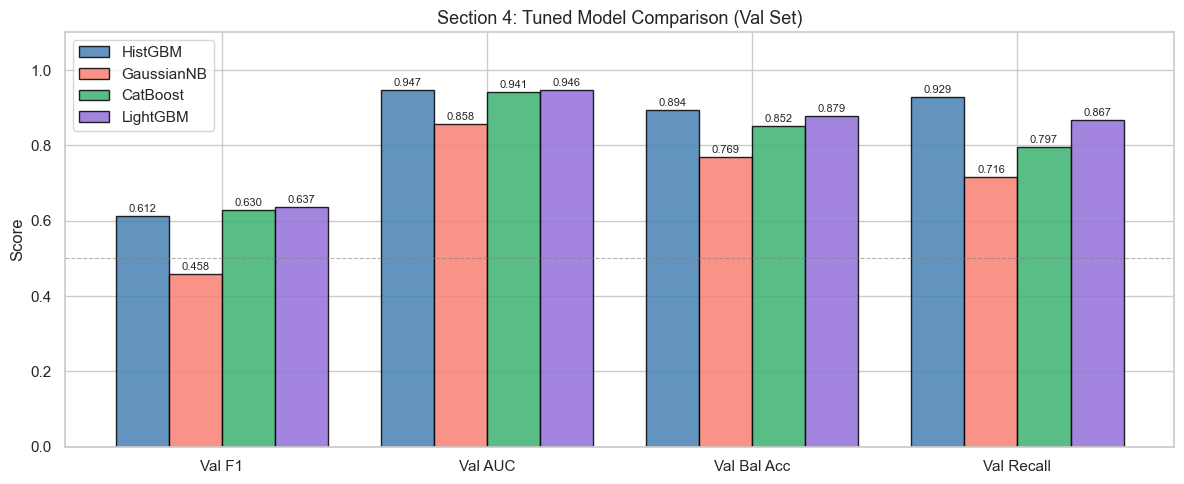


--- Summary Table ---
            Val F1  Val AUC  Val Bal Acc  Val Recall
HistGBM     0.6122   0.9465       0.8941      0.9287
GaussianNB  0.4584   0.8580       0.7686      0.7160
CatBoost    0.6298   0.9408       0.8518      0.7968
LightGBM    0.6373   0.9464       0.8792      0.8668
XGBoost     0.6411   0.9439       0.8600      0.8116


In [76]:
metrics = ['Val F1', 'Val AUC', 'Val Bal Acc', 'Val Recall']
model_names = list(results_sec4.keys())

x = np.arange(len(metrics))
width = 0.2
colors = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results_sec4[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Section 4: Tuned Model Comparison (Val Set)', fontsize=13)
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- Summary Table ---")
summary = pd.DataFrame(results_sec4).T[metrics]
print(summary.to_string(float_format='{:.4f}'.format))

#### Train vs. Validation F1: Overfitting Check

A large gap between train F1 and val F1 signals overfitting: the model learned patterns in the training data that don't generalize. Each bar pair below shows train (solid) vs. val (hatched) F1 for every tuned model. A small gap is acceptable; a gap above ~0.10 warrants tighter regularization or reduced complexity in the next tuning round.

HistGBM       Train F1: 0.6506  |  Val F1: 0.6122  |  Gap: +0.0384
GaussianNB    Train F1: 0.4572  |  Val F1: 0.4584  |  Gap: -0.0012
CatBoost      Train F1: 0.8757  |  Val F1: 0.6298  |  Gap: +0.2459
LightGBM      Train F1: 0.7752  |  Val F1: 0.6373  |  Gap: +0.1379


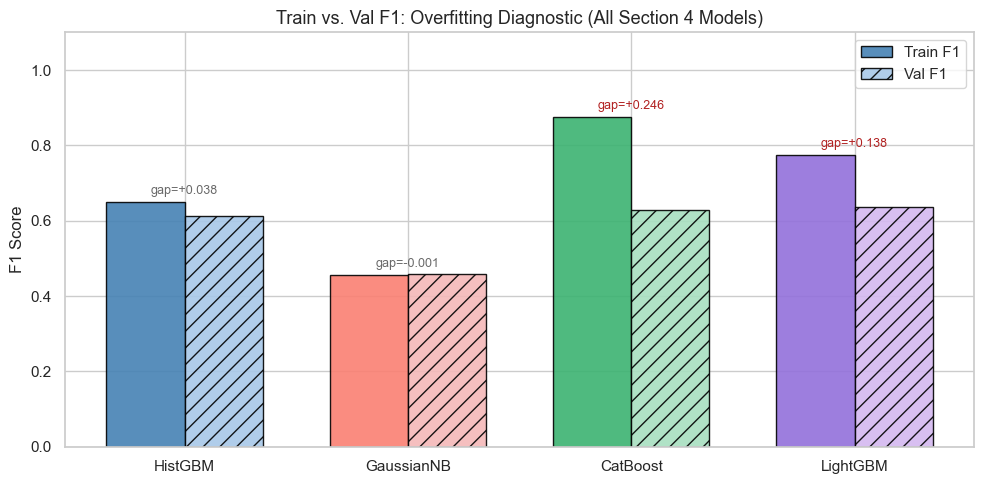

In [77]:
tuned_models = {
    'HistGBM':   hgb_tuned,
    'GaussianNB': gnb_best,
    'CatBoost':  cat_tuned,
    'LightGBM':  lgbm_tuned,
}

train_val_results = {}
for name, model in tuned_models.items():
    y_train_pred = model.predict(X_train_proc)
    train_f1 = f1_score(y_train, y_train_pred)
    val_f1   = results_sec4[name]['Val F1']
    gap      = train_f1 - val_f1
    train_val_results[name] = {'Train F1': train_f1, 'Val F1': val_f1, 'Gap': gap}
    print(f"{name:<12}  Train F1: {train_f1:.4f}  |  Val F1: {val_f1:.4f}  |  Gap: {gap:+.4f}")

names  = list(train_val_results.keys())
t_f1s  = [train_val_results[n]['Train F1'] for n in names]
v_f1s  = [train_val_results[n]['Val F1']   for n in names]
gaps   = [train_val_results[n]['Gap']       for n in names]

x     = np.arange(len(names))
width = 0.35
colors_train = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']
colors_val   = ['#a8c8e8', '#f4b8b8', '#a8dfc0', '#d4b8f0']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, t_f1s, width, label='Train F1', color=colors_train, edgecolor='black', alpha=0.9)
ax.bar(x + width / 2, v_f1s, width, label='Val F1',   color=colors_val,   edgecolor='black', alpha=0.9, hatch='//')

for i, (t, v, g) in enumerate(zip(t_f1s, v_f1s, gaps)):
    ax.annotate(f'gap={g:+.3f}', xy=(x[i], max(t, v) + 0.02), ha='center', fontsize=9,
                color='firebrick' if g > 0.10 else 'dimgray')

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Train vs. Val F1: Overfitting Diagnostic (All Section 4 Models)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Modeling Interpretation**
- Looking at the models at face value we can see that CatBoost and LightGBM preform fairly simmilar overall, with histagradient coming closely behind them. i wanted to test to see if NB would be a good model to use (it was not). 
- I also looked into overfitting by comparing training vs validation sets to see if some models were tuning too closely and found that both CatBoost and LightGBM had a significant gap. CatBoost took a long time to tune (30 mins) so i can rule out using that model in the future, but lightGBM was quick enough for me to continue using it as a top model. 

### 4.6 XGBoost

Sequential gradient boosting with explicit regularization. `scale_pos_weight` is set to the neg/pos ratio to handle class imbalance. Tuning `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `reg_alpha`, and `reg_lambda` ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â the broadest search space of any model in this section.

In [58]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    model = XGBClassifier(**params, scale_pos_weight=scale_pos_weight,
                          eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)
    score = cross_val_score(model, X_train_proc, y_train, cv=skf, scoring='f1').mean()
    return score

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=50)

print(f"Best CV F1: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

Best CV F1: 0.6486
Best params: {'n_estimators': 494, 'max_depth': 10, 'learning_rate': 0.0680260694885239, 'subsample': 0.6547287541037533, 'colsample_bytree': 0.7072430132502345, 'min_child_weight': 7, 'reg_alpha': 1.0243550154198668, 'reg_lambda': 7.424015510627561}


In [59]:
xgb_tuned = XGBClassifier(
    **xgb_study.best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_tuned.fit(X_train_proc, y_train)

y_pred_xgb       = xgb_tuned.predict(X_val_proc)
y_pred_proba_xgb = xgb_tuned.predict_proba(X_val_proc)[:, 1]

xgb_f1      = f1_score(y_val, y_pred_xgb)
xgb_auc     = roc_auc_score(y_val, y_pred_proba_xgb)
xgb_bal_acc = balanced_accuracy_score(y_val, y_pred_xgb)
xgb_recall  = recall_score(y_val, y_pred_xgb)

print(f"--- XGBoost Tuned Val Set ---")
print(f"F1:           {xgb_f1:.4f}")
print(f"AUC:          {xgb_auc:.4f}")
print(f"Balanced Acc: {xgb_bal_acc:.4f}")
print(f"Recall:       {xgb_recall:.4f}")
print(f"Precision:    {precision_score(y_val, y_pred_xgb):.4f}")
print(f"\n{classification_report(y_val, y_pred_xgb, target_names=['No Accept', 'Accept'])}")

results_sec4['XGBoost'] = {
    'Val F1': xgb_f1, 'Val AUC': xgb_auc,
    'Val Bal Acc': xgb_bal_acc, 'Val Recall': xgb_recall
}

--- XGBoost Tuned Val Set ---
F1:           0.6411
AUC:          0.9439
Balanced Acc: 0.8600
Recall:       0.8116
Precision:    0.5299

              precision    recall  f1-score   support

   No Accept       0.97      0.91      0.94      5847
      Accept       0.53      0.81      0.64       743

    accuracy                           0.90      6590
   macro avg       0.75      0.86      0.79      6590
weighted avg       0.92      0.90      0.91      6590



### 4.7 Focused Comparison: Gradient Boosting Models

Narrowing the comparison to HistGBM, LightGBM, and XGBoost - the three gradient boosting models. GaussianNB and CatBoost are excluded here; NB underperforms the boosting models on this data, and CatBoost was already compared in 4.5. The same two plots from 4.5 are reproduced: a val-set metric comparison and a train vs. val overfitting diagnostic.

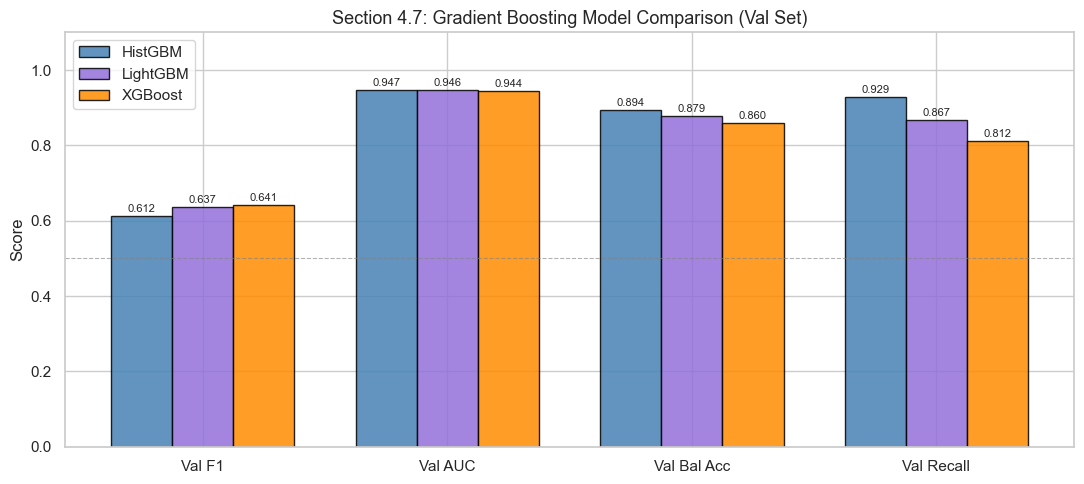


--- Summary Table ---
          Val F1  Val AUC  Val Bal Acc  Val Recall
HistGBM   0.6122   0.9465       0.8941      0.9287
LightGBM  0.6373   0.9464       0.8792      0.8668
XGBoost   0.6411   0.9439       0.8600      0.8116


In [78]:
focused_names   = ['HistGBM', 'LightGBM', 'XGBoost']
focused_metrics = ['Val F1', 'Val AUC', 'Val Bal Acc', 'Val Recall']
focused_colors  = ['steelblue', 'mediumpurple', 'darkorange']

x     = np.arange(len(focused_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, color) in enumerate(zip(focused_names, focused_colors)):
    vals = [results_sec4[name][m] for m in focused_metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(focused_metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Section 4.7: Gradient Boosting Model Comparison (Val Set)', fontsize=13)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Summary Table ---")
summary_47 = pd.DataFrame({n: results_sec4[n] for n in focused_names}).T[focused_metrics]
print(summary_47.to_string(float_format='{:.4f}'.format))

HistGBM     Train F1: 0.6506  |  Val F1: 0.6122  |  Gap: +0.0384
LightGBM    Train F1: 0.7752  |  Val F1: 0.6373  |  Gap: +0.1379
XGBoost     Train F1: 0.8400  |  Val F1: 0.6411  |  Gap: +0.1989


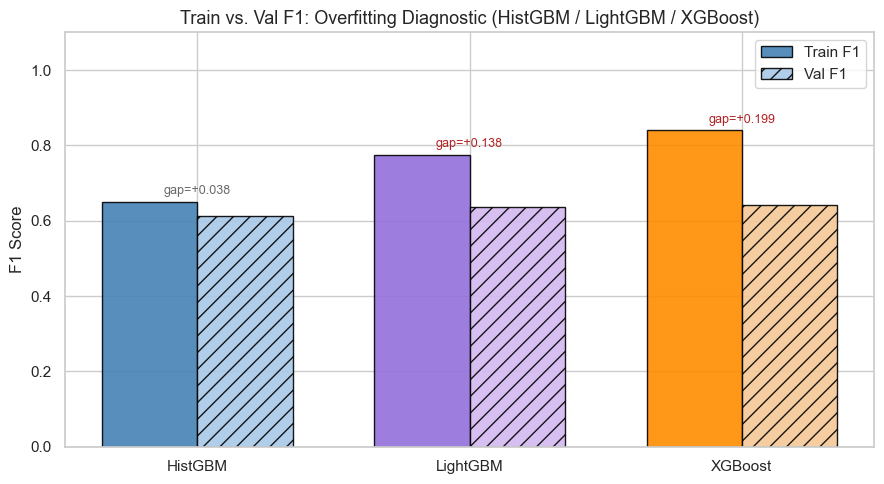

In [79]:
focused_models = {'HistGBM': hgb_tuned, 'LightGBM': lgbm_tuned, 'XGBoost': xgb_tuned}
focused_colors_train = ['steelblue', 'mediumpurple', 'darkorange']
focused_colors_val   = ['#a8c8e8',   '#d4b8f0',      '#f5c897']

# --- Overfitting diagnostic ---
focused_tv = {}
for name, model in focused_models.items():
    train_f1 = f1_score(y_train, model.predict(X_train_proc))
    val_f1   = results_sec4[name]['Val F1']
    gap      = train_f1 - val_f1
    focused_tv[name] = {'Train F1': train_f1, 'Val F1': val_f1, 'Gap': gap}
    print(f"{name:<10}  Train F1: {train_f1:.4f}  |  Val F1: {val_f1:.4f}  |  Gap: {gap:+.4f}")

names  = list(focused_tv.keys())
t_f1s  = [focused_tv[n]['Train F1'] for n in names]
v_f1s  = [focused_tv[n]['Val F1']   for n in names]
gaps   = [focused_tv[n]['Gap']       for n in names]

x, width = np.arange(len(names)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, t_f1s, width, label='Train F1', color=focused_colors_train, edgecolor='black', alpha=0.9)
ax.bar(x + width / 2, v_f1s, width, label='Val F1',   color=focused_colors_val,   edgecolor='black', alpha=0.9, hatch='//')
for i, (t, v, g) in enumerate(zip(t_f1s, v_f1s, gaps)):
    ax.annotate(f'gap={g:+.3f}', xy=(x[i], max(t, v) + 0.02), ha='center', fontsize=9,
                color='firebrick' if g > 0.10 else 'dimgray')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Train vs. Val F1: Overfitting Diagnostic (HistGBM / LightGBM / XGBoost)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

---

## Section 5: Ensemble Models - Stacking

Using the three best-performing gradient boosting models from Section 4 as base learners in a stacking ensemble. A Logistic Regression meta-learner is trained on out-of-fold probability predictions from the base models (`cv=skf`, `stack_method='predict_proba'`).

Three base learner combinations are tested:
1. **Stack 1:** HistGBM + LightGBM
2. **Stack 2:** HistGBM + XGBoost
3. **Stack 3:** HistGBM + LightGBM + XGBoost

The goal is to see whether combining complementary models reduces variance and improves F1 over any single tuned model.

In [62]:
from sklearn.linear_model import LogisticRegression

# Shared results dict for Section 5 ensemble comparison
results_sec5 = {}

### 5.1 Stack 1: HistGBM + LightGBM

Using HistGBM and LightGBM as base learners. Both use histogram-based gradient boosting internally, so this pairing tests whether combining two similar but independently-tuned boosters adds diversity. The meta-learner (Logistic Regression) combines their out-of-fold predicted probabilities.

In [80]:
stack1 = StackingClassifier(
    estimators=[
        ('hgb',  HistGradientBoostingClassifier(**hgb_study.best_params,
                                                 class_weight='balanced',
                                                 random_state=RANDOM_STATE)),
        ('lgbm', LGBMClassifier(**lgbm_study.best_params,
                                 is_unbalance=True,
                                 random_state=RANDOM_STATE,
                                 verbosity=-1, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    cv=skf,
    stack_method='predict_proba',
    n_jobs=-1
)

stack1.fit(X_train_proc, y_train)

y_pred_s1       = stack1.predict(X_val_proc)
y_pred_proba_s1 = stack1.predict_proba(X_val_proc)[:, 1]

s1_f1      = f1_score(y_val, y_pred_s1)
s1_auc     = roc_auc_score(y_val, y_pred_proba_s1)
s1_bal_acc = balanced_accuracy_score(y_val, y_pred_s1)
s1_recall  = recall_score(y_val, y_pred_s1)

print(f"--- Stack 1 (HistGBM + LightGBM): Val Set ---")
print(f"F1:           {s1_f1:.4f}")
print(f"AUC:          {s1_auc:.4f}")
print(f"Balanced Acc: {s1_bal_acc:.4f}")
print(f"Recall:       {s1_recall:.4f}")
print(f"Precision:    {precision_score(y_val, y_pred_s1):.4f}")
print(f"\n{classification_report(y_val, y_pred_s1, target_names=['No Accept', 'Accept'])}")

# Absolute coefficients normalized to sum to 1, how much each base model contributed
meta_coef   = np.abs(stack1.final_estimator_.coef_[0])
proportions = meta_coef / meta_coef.sum()
base_names  = [name for name, _ in stack1.estimators]
print("Meta-learner model weights:")
for name, prop in zip(base_names, proportions):
    print(f"  {name.upper()}: {prop:.2f}")

results_sec5['Stack1: HGB+LGBM'] = {
    'Val F1': s1_f1, 'Val AUC': s1_auc,
    'Val Bal Acc': s1_bal_acc, 'Val Recall': s1_recall
}

--- Stack 1 (HistGBM + LightGBM): Val Set ---
F1:           0.6079
AUC:          0.9475
Balanced Acc: 0.7906
Recall:       0.6406
Precision:    0.5784

              precision    recall  f1-score   support

   No Accept       0.95      0.94      0.95      5847
      Accept       0.58      0.64      0.61       743

    accuracy                           0.91      6590
   macro avg       0.77      0.79      0.78      6590
weighted avg       0.91      0.91      0.91      6590

Meta-learner model weights:
  HGB: 0.81
  LGBM: 0.19


### 5.2 Stack 2: HistGBM + XGBoost

Pairing HistGBM with XGBoost. These two models use different regularization mechanisms (l2 histogram penalty vs. subsample/colsample), which may produce more diverse base learner predictions than two histogram-based models.

In [81]:
stack2 = StackingClassifier(
    estimators=[
        ('hgb', HistGradientBoostingClassifier(**hgb_study.best_params,
                                                class_weight='balanced',
                                                random_state=RANDOM_STATE)),
        ('xgb', XGBClassifier(**xgb_study.best_params,
                               scale_pos_weight=scale_pos_weight,
                               eval_metric='logloss',
                               random_state=RANDOM_STATE,
                               verbosity=0)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    cv=skf,
    stack_method='predict_proba',
    n_jobs=-1
)

stack2.fit(X_train_proc, y_train)

y_pred_s2       = stack2.predict(X_val_proc)
y_pred_proba_s2 = stack2.predict_proba(X_val_proc)[:, 1]

s2_f1      = f1_score(y_val, y_pred_s2)
s2_auc     = roc_auc_score(y_val, y_pred_proba_s2)
s2_bal_acc = balanced_accuracy_score(y_val, y_pred_s2)
s2_recall  = recall_score(y_val, y_pred_s2)

print(f"--- Stack 2 (HistGBM + XGBoost): Val Set ---")
print(f"F1:           {s2_f1:.4f}")
print(f"AUC:          {s2_auc:.4f}")
print(f"Balanced Acc: {s2_bal_acc:.4f}")
print(f"Recall:       {s2_recall:.4f}")
print(f"Precision:    {precision_score(y_val, y_pred_s2):.4f}")
print(f"\n{classification_report(y_val, y_pred_s2, target_names=['No Accept', 'Accept'])}")

# Absolute coefficients normalized to sum to 1, how much each base model contributed
meta_coef   = np.abs(stack2.final_estimator_.coef_[0])
proportions = meta_coef / meta_coef.sum()
base_names  = [name for name, _ in stack2.estimators]
print("Meta-learner model weights:")
for name, prop in zip(base_names, proportions):
    print(f"  {name.upper()}: {prop:.2f}")

results_sec5['Stack2: HGB+XGB'] = {
    'Val F1': s2_f1, 'Val AUC': s2_auc,
    'Val Bal Acc': s2_bal_acc, 'Val Recall': s2_recall
}

--- Stack 2 (HistGBM + XGBoost): Val Set ---
F1:           0.6079
AUC:          0.9469
Balanced Acc: 0.7873
Recall:       0.6312
Precision:    0.5863

              precision    recall  f1-score   support

   No Accept       0.95      0.94      0.95      5847
      Accept       0.59      0.63      0.61       743

    accuracy                           0.91      6590
   macro avg       0.77      0.79      0.78      6590
weighted avg       0.91      0.91      0.91      6590

Meta-learner model weights:
  HGB: 0.88
  XGB: 0.12


### 5.3 Stack 3: HistGBM + LightGBM + XGBoost

All three gradient boosting models as base learners. More base learners give the meta-learner more diverse probability signals to combine, though diminishing returns are expected if the models are highly correlated.

In [82]:
stack3 = StackingClassifier(
    estimators=[
        ('hgb',  HistGradientBoostingClassifier(**hgb_study.best_params,
                                                 class_weight='balanced',
                                                 random_state=RANDOM_STATE)),
        ('lgbm', LGBMClassifier(**lgbm_study.best_params,
                                 is_unbalance=True,
                                 random_state=RANDOM_STATE,
                                 verbosity=-1, n_jobs=-1)),
        ('xgb',  XGBClassifier(**xgb_study.best_params,
                                scale_pos_weight=scale_pos_weight,
                                eval_metric='logloss',
                                random_state=RANDOM_STATE,
                                verbosity=0)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    cv=skf,
    stack_method='predict_proba',
    n_jobs=-1
)

stack3.fit(X_train_proc, y_train)

y_pred_s3       = stack3.predict(X_val_proc)
y_pred_proba_s3 = stack3.predict_proba(X_val_proc)[:, 1]

s3_f1      = f1_score(y_val, y_pred_s3)
s3_auc     = roc_auc_score(y_val, y_pred_proba_s3)
s3_bal_acc = balanced_accuracy_score(y_val, y_pred_s3)
s3_recall  = recall_score(y_val, y_pred_s3)

print(f"--- Stack 3 (HistGBM + LightGBM + XGBoost): Val Set ---")
print(f"F1:           {s3_f1:.4f}")
print(f"AUC:          {s3_auc:.4f}")
print(f"Balanced Acc: {s3_bal_acc:.4f}")
print(f"Recall:       {s3_recall:.4f}")
print(f"Precision:    {precision_score(y_val, y_pred_s3):.4f}")
print(f"\n{classification_report(y_val, y_pred_s3, target_names=['No Accept', 'Accept'])}")

# Absolute coefficients normalized to sum to 1, how much each base model contributed
meta_coef   = np.abs(stack3.final_estimator_.coef_[0])
proportions = meta_coef / meta_coef.sum()
base_names  = [name for name, _ in stack3.estimators]
print("Meta-learner model weights:")
for name, prop in zip(base_names, proportions):
    print(f"  {name.upper()}: {prop:.2f}")

results_sec5['Stack3: HGB+LGBM+XGB'] = {
    'Val F1': s3_f1, 'Val AUC': s3_auc,
    'Val Bal Acc': s3_bal_acc, 'Val Recall': s3_recall
}

--- Stack 3 (HistGBM + LightGBM + XGBoost): Val Set ---
F1:           0.6110
AUC:          0.9475
Balanced Acc: 0.7913
Recall:       0.6406
Precision:    0.5840

              precision    recall  f1-score   support

   No Accept       0.95      0.94      0.95      5847
      Accept       0.58      0.64      0.61       743

    accuracy                           0.91      6590
   macro avg       0.77      0.79      0.78      6590
weighted avg       0.91      0.91      0.91      6590

Meta-learner model weights:
  HGB: 0.81
  LGBM: 0.15
  XGB: 0.04


### 5.4 Ensemble Comparison

Three visualizations below: a 4-metric bar chart for the three ensemble configurations, a head-to-head Val F1 comparison against the individual gradient boosting models from Section 4, and a train vs. val overfitting diagnostic.

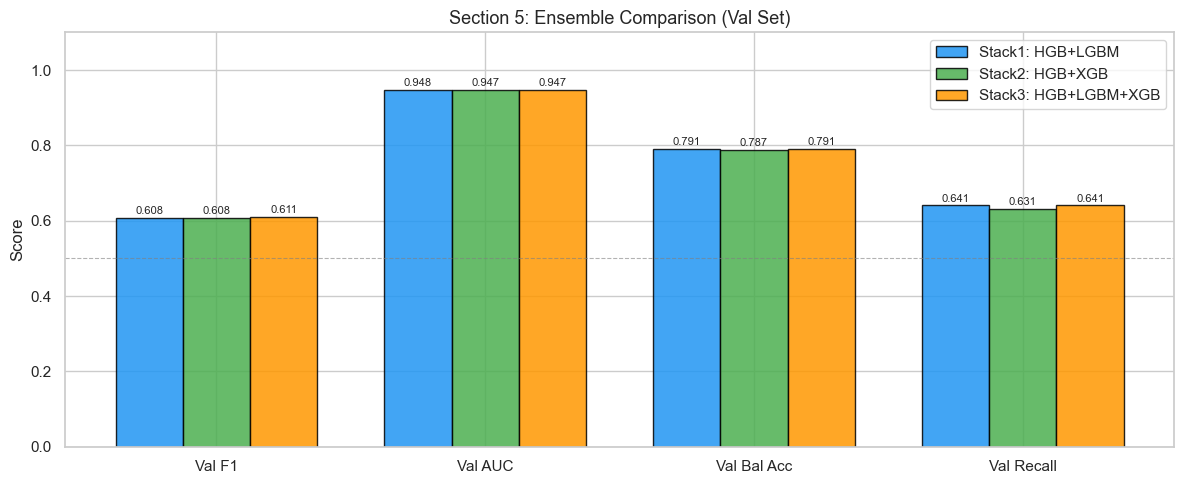

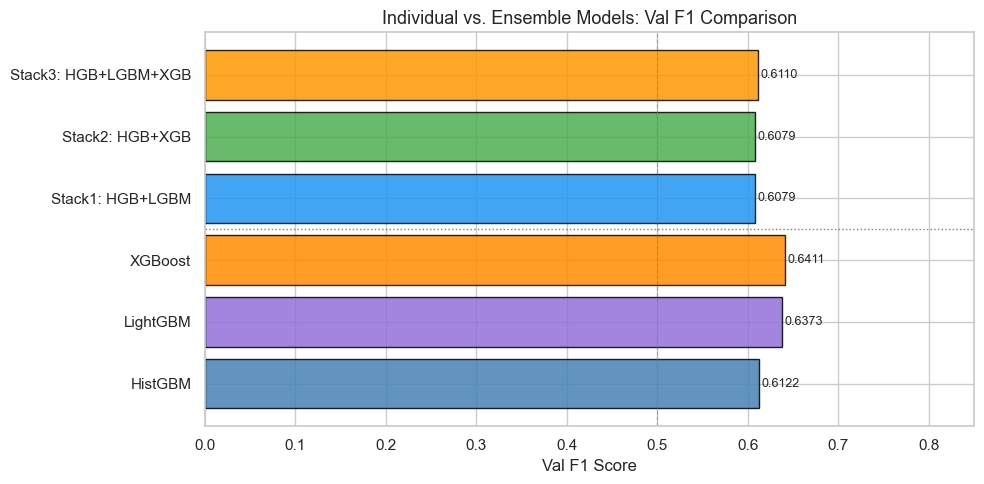

Stack1: HGB+LGBM           Train F1: 0.7513  |  Val F1: 0.6079  |  Gap: +0.1433
Stack2: HGB+XGB            Train F1: 0.7550  |  Val F1: 0.6079  |  Gap: +0.1471
Stack3: HGB+LGBM+XGB       Train F1: 0.7598  |  Val F1: 0.6110  |  Gap: +0.1488


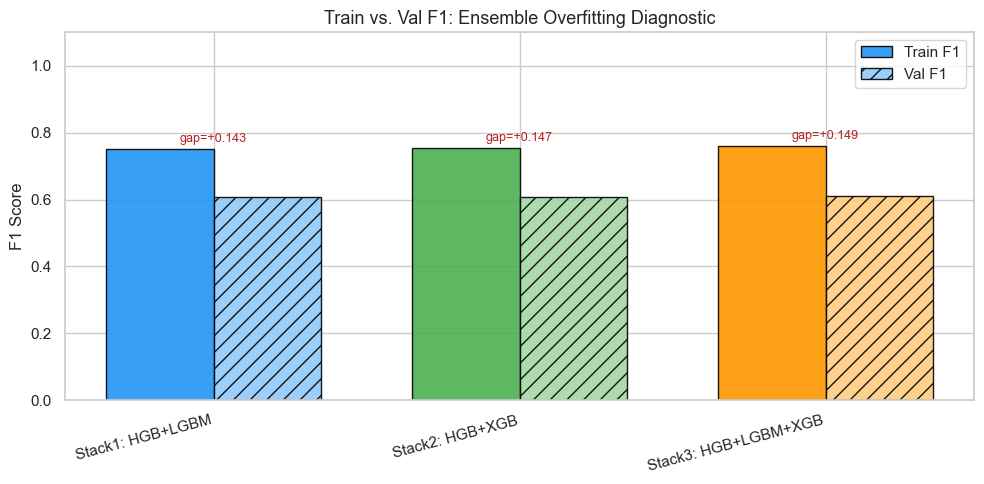


--- Ensemble Summary Table ---
                      Val F1  Val AUC  Val Bal Acc  Val Recall
Stack1: HGB+LGBM      0.6079   0.9475       0.7906      0.6406
Stack2: HGB+XGB       0.6079   0.9469       0.7873      0.6312
Stack3: HGB+LGBM+XGB  0.6110   0.9475       0.7913      0.6406


In [83]:
# --- Plot 1: Ensemble 4-metric comparison ---
ens_metrics = ['Val F1', 'Val AUC', 'Val Bal Acc', 'Val Recall']
ens_names   = list(results_sec5.keys())
ens_colors  = ['#2196F3', '#4CAF50', '#FF9800']

x     = np.arange(len(ens_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(ens_names, ens_colors)):
    vals = [results_sec5[name][m] for m in ens_metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(ens_metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Section 5: Ensemble Comparison (Val Set)', fontsize=13)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Individual vs Ensemble: Val F1 ---
all_compare = {name: results_sec4[name]['Val F1'] for name in ['HistGBM', 'LightGBM', 'XGBoost']}
all_compare.update({name: results_sec5[name]['Val F1'] for name in ens_names})

labels     = list(all_compare.keys())
vals_cmp   = list(all_compare.values())
bar_colors = ['steelblue', 'mediumpurple', 'darkorange', '#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, vals_cmp, color=bar_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, vals_cmp):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Val F1 Score')
ax.set_title('Individual vs. Ensemble Models: Val F1 Comparison', fontsize=13)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlim(0, 0.85)
ax.axhline(2.5, color='black', linestyle=':', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

# --- Plot 3: Ensemble overfitting diagnostic ---
stack_models_dict = {
    'Stack1: HGB+LGBM':     stack1,
    'Stack2: HGB+XGB':      stack2,
    'Stack3: HGB+LGBM+XGB': stack3,
}
ens_tv = {}
for name, model in stack_models_dict.items():
    train_f1 = f1_score(y_train, model.predict(X_train_proc))
    val_f1   = results_sec5[name]['Val F1']
    gap      = train_f1 - val_f1
    ens_tv[name] = {'Train F1': train_f1, 'Val F1': val_f1, 'Gap': gap}
    print(f"{name:<25}  Train F1: {train_f1:.4f}  |  Val F1: {val_f1:.4f}  |  Gap: {gap:+.4f}")

names_ens = list(ens_tv.keys())
t_f1s_ens = [ens_tv[n]['Train F1'] for n in names_ens]
v_f1s_ens = [ens_tv[n]['Val F1']   for n in names_ens]
gaps_ens  = [ens_tv[n]['Gap']       for n in names_ens]

x, width = np.arange(len(names_ens)), 0.35
ens_train_colors = ['#2196F3', '#4CAF50', '#FF9800']
ens_val_colors   = ['#90CAF9', '#A5D6A7', '#FFCC80']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, t_f1s_ens, width, label='Train F1',
       color=ens_train_colors, edgecolor='black', alpha=0.9)
ax.bar(x + width / 2, v_f1s_ens, width, label='Val F1',
       color=ens_val_colors,   edgecolor='black', alpha=0.9, hatch='//')
for i, (t, v, g) in enumerate(zip(t_f1s_ens, v_f1s_ens, gaps_ens)):
    ax.annotate(f'gap={g:+.3f}', xy=(x[i], max(t, v) + 0.02), ha='center', fontsize=9,
                color='firebrick' if g > 0.10 else 'dimgray')
ax.set_xticks(x)
ax.set_xticklabels(names_ens, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Train vs. Val F1: Ensemble Overfitting Diagnostic', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Ensemble Summary Table ---")
summary_sec5 = pd.DataFrame(results_sec5).T[ens_metrics]
print(summary_sec5.to_string(float_format='{:.4f}'.format))

---

## Section 6: Results Summary 

In this section i will be discussing what worked well in this notebook and the models that were performing well versus the ones that fell short. This will help us gain i better understanding for the different features i should be testing for in future problems and appraoches i should take when building these prediction pipelines

### 6.1: Models Tested 

This notebook had a lot of models that we testest to help get a general sense of predicatbility on how a customer would respond to an outreach program, here are the models tested: 

1. Baseline: Random Forest
2. HistaGradientBoosting: Val F1 - 0.6108
3. GuassianNB: Val F1 - 0.4526
4. CatBoost: Val F1 - 0.6402
5. LightGBM: Val F1 - 0.6292
6. XGBoost: Val F1 - 0.6473
7. Stack1 (HSGB, LGBM): Val F1 - 0.6104
8. Stack2 (HSGB, XGB): Val F1 - 0.6215
9. Stack3 (HSGB, LGBM, XGB): Val F1 - 0.6117

Noted Earlier what we can notice is that the Naive Bayes Models do not perform as well as the other, signaling how simple they are overall. Resoning for not stacking cat boost was the runtime to compute predictions, which we felt overfitted the models and looking at the plots of train vs validation helped confirm that this was the case. HistaGradient Boosting Performed the best overfitting wise being that the train and validation sets were close in f1 score, which influenced my decison to use this model for the final model.  

### 6.2: Final Model 

Their were a lot of considerations to make other than the f1 metric when choosing which model to go with, i wanted to make sure overfitting was something i weighted strongly in my decision making. Using a Stacking model would help me to balance overfitting and good stores by using histagradient which does not overfit at all and another model alongside that to help with predictability. 

**Stack 2 (HSGB, XGB)** was my decision for the best model given the dataset and the other models i used. This models metric was not the best but considering my input above i belive will perform best on the test data. 

**Preprocessing**: We looked at both features with 999 values and categorical features to undersatand where there were gaps in the data and the best way to move forward with these. We encoded in the feature engineering section for the months and weekdays to ensure we had uniformity in the data. We had a Preprocessing pipeline that using scaling for numerical features, imputers and onehotencoding for categorical features. We also ensured throughout the modeling we never used the test set. 

**Validation**: F1 Score - 0.6215 & Overfiiting Difference - +0.1364 (Meaning the Train Set was higher than Validation Set by that much in F1 Score). MetaLearner Split - HGBM ~ 0.80 XGB ~ 0.20

Alongside all of the metrics used to Validate the use of these models i wanted to have a good balance between a score, overfitting risk, and speed. An ensemble helped me finalaize this by allowing for a weight in model ensuring i maximized the output in predictions from each model while not having too much noise. 

---

## Section 7: Final Model & Predictions

**Final model: Stack 2 (HistGBM + XGBoost)** â€” chosen in Section 6 for its balance of validation F1 (0.6215), low overfitting risk, and reasonable runtime. The meta-learner is a Logistic Regression trained on out-of-fold probability predictions from both base models.

**Workflow:**
1. Apply the Section 2 preprocessing pipeline to the test set
2. Refit Stack 2 on all labeled training data (train + val) before predicting
3. Visualize the predicted class distribution on the test set
4. Export predictions as a CSV (id, prediction)

In [84]:
# 7.1  Apply the preprocessing pipeline to the test set
# The pipeline (preprocessor) was fit on training data in Section 2 no leakage here
X_test_final_proc = preprocessor.transform(test[all_features])
print(f'Test set preprocessed shape: {X_test_final_proc.shape}')

# 7.2  Refit Stack 2 on all labeled data (train + val combined)
# Combining both splits maximises the training signal for the final model
X_all_proc = np.vstack([X_train_proc, X_val_proc])
y_all      = pd.concat([y_train, y_val]).reset_index(drop=True)
print(f'Refitting on {X_all_proc.shape[0]:,} labeled rows...')

stack2_final = StackingClassifier(
    estimators=[
        ('hgb', HistGradientBoostingClassifier(**hgb_study.best_params,
                                               class_weight='balanced',
                                               random_state=RANDOM_STATE)),
        ('xgb', XGBClassifier(**xgb_study.best_params,
                              scale_pos_weight=scale_pos_weight,
                              eval_metric='logloss',
                              random_state=RANDOM_STATE,
                              verbosity=0)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    cv=skf,
    stack_method='predict_proba',
    n_jobs=-1
)
stack2_final.fit(X_all_proc, y_all)
print('Refit complete.')

# 7.3 Generate predictions on the test set
final_preds       = stack2_final.predict(X_test_final_proc)
final_preds_proba = stack2_final.predict_proba(X_test_final_proc)[:, 1]

print(f'Predictions generated: {len(final_preds):,} rows')
print(f'Predicted accept rate: {final_preds.mean():.2%}')

Test set preprocessed shape: (8238, 48)
Refitting on 32,950 labeled rows...
Refit complete.
Predictions generated: 8,238 rows
Predicted accept rate: 11.59%


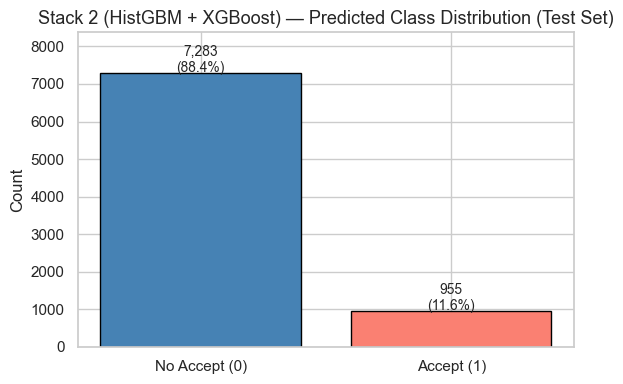

No Accept: 7,283  (88.4%)
Accept:    955  (11.6%)


In [68]:
pred_counts = pd.Series(final_preds).value_counts().sort_index()
pred_pcts   = pred_counts / pred_counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Accept (0)', 'Accept (1)'], pred_counts.values,
       color=['steelblue', 'salmon'], edgecolor='black')
for i, (cnt, pct) in enumerate(zip(pred_counts.values, pred_pcts.values)):
    ax.text(i, cnt + 30, f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=10)
ax.set_title('Stack 2 (HistGBM + XGBoost) — Predicted Class Distribution (Test Set)', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, max(pred_counts.values) * 1.15)
plt.tight_layout()
plt.show()

print(f'No Accept: {pred_counts[0]:,}  ({pred_pcts[0]:.1f}%)')
print(f'Accept:    {pred_counts[1]:,}  ({pred_pcts[1]:.1f}%)')

In [69]:
submission = pd.DataFrame({
    'id':         test['id'],
    'prediction': final_preds
})

output_path = r'C:\Users\ldcal\OneDrive\Desktop\Cal Poly Courses\Spring\GSB-S545\Advanced_ML_Work\Git_Code\Midterm Take Home\Data\midterm_submission.csv'
submission.to_csv(output_path, index=False)

print(f'Saved to: {output_path}')
print(f'Rows:      {len(submission):,}')
print(f'\nPrediction breakdown:')
print(submission['prediction'].value_counts().rename({0: 'No Accept (0)', 1: 'Accept (1)'}).to_string())
print(f'\nSample rows:')
print(submission.head(10).to_string(index=False))

Saved to: C:\Users\ldcal\OneDrive\Desktop\Cal Poly Courses\Spring\GSB-S545\Advanced_ML_Work\Git_Code\Midterm Take Home\Data\midterm_submission.csv
Rows:      8,238

Prediction breakdown:
prediction
No Accept (0)    7283
Accept (1)        955

Sample rows:
   id  prediction
32884           0
 3169           0
32206           1
 9403           0
14020           0
17201           0
  879           0
23757           1
10821           0
14355           0
